<a href="https://colab.research.google.com/github/rohaan2614/Federated_Learning/blob/master/Data_Center_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup and Data Preparation

In [17]:
!pip install torch torchvision

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

# Configuration
BATCH_SIZE = 32
NUM_CLIENTS = 10  # Simulate 10 clients
EPOCHS = 20

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split dataset among clients
client_datasets = torch.utils.data.random_split(train_dataset, [len(train_dataset)//NUM_CLIENTS]*NUM_CLIENTS)
client_loaders = [DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True) for dataset in client_datasets]

# Download and load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


### Model Definition

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64*24*24, 128)  # Adjusted based on actual output size
        self.fc2 = nn.Linear(128, 10)
        print("Model initialized!")

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(-1, 64*24*24)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate model
global_model = SimpleCNN()

Model initialized!


### Training & Evaluate

In [20]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(global_model.parameters(), lr=0.001)

In [21]:
def evaluate(model, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = val_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [22]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Evaluate on validation data
        avg_val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    return train_losses, val_losses, val_accuracies

# Train the global model on one client's data to simulate data center learning
train_losses, val_losses, val_accuracies = train(global_model, client_loaders[0], test_loader, criterion, optimizer, epochs=EPOCHS)


Epoch 1/20, Training Loss: 0.3589, Validation Loss: 0.1853, Validation Accuracy: 0.9442
Epoch 2/20, Training Loss: 0.0781, Validation Loss: 0.1050, Validation Accuracy: 0.9688
Epoch 3/20, Training Loss: 0.0262, Validation Loss: 0.1123, Validation Accuracy: 0.9677
Epoch 4/20, Training Loss: 0.0248, Validation Loss: 0.1718, Validation Accuracy: 0.9534
Epoch 5/20, Training Loss: 0.0186, Validation Loss: 0.1483, Validation Accuracy: 0.9661
Epoch 6/20, Training Loss: 0.0025, Validation Loss: 0.1275, Validation Accuracy: 0.9722
Epoch 7/20, Training Loss: 0.0032, Validation Loss: 0.1577, Validation Accuracy: 0.9685
Epoch 8/20, Training Loss: 0.0038, Validation Loss: 0.1612, Validation Accuracy: 0.9627
Epoch 9/20, Training Loss: 0.0289, Validation Loss: 0.1826, Validation Accuracy: 0.9551
Epoch 10/20, Training Loss: 0.0234, Validation Loss: 0.1495, Validation Accuracy: 0.9681
Epoch 11/20, Training Loss: 0.0206, Validation Loss: 0.1430, Validation Accuracy: 0.9696
Epoch 12/20, Training Loss: 0.

### Plotting

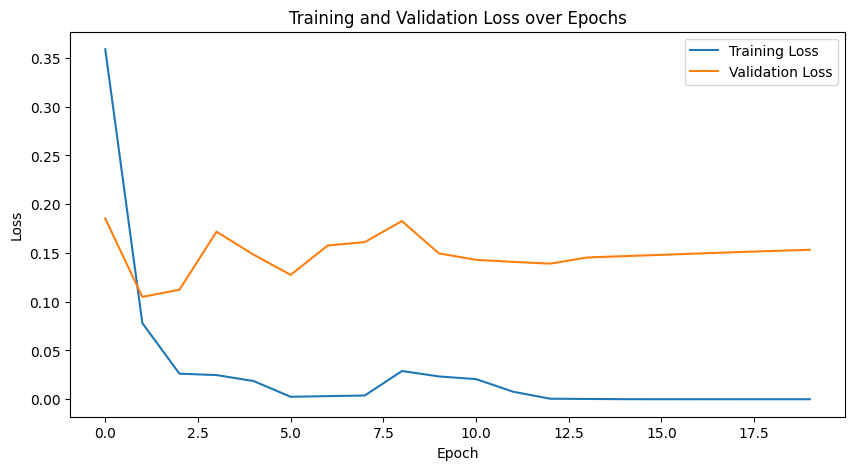

In [23]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()